18 18
[197, 282, 118, 153, 247, 137, 107, 225, 141, 11, 186, 126, 65, 30, 233, 236, 232, 167]
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 300
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (linux64 - "Debian GNU/Linux 12 (bookworm)")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 2 physical cores, 4 logical processors, using up to 4 threads

Non-default parameters:
TimeLimit  300

Academic license 937859 - for non-commercial use only - registered to hp___@cornell.edu
Optimize a model with 489190 rows, 162783 columns and 1137532 nonzeros (Min)
Model fingerprint: 0x78d9828a
Model has 275 linear objective coefficients
Variable types: 162504 continuous, 279 integer (279 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [1e+00, 1e+02]
  RHS range        [1e+00, 1e+02]

Presolve removed 166996 rows and 10 columns
Presolve time: 4.09s
Presolved: 322194 r

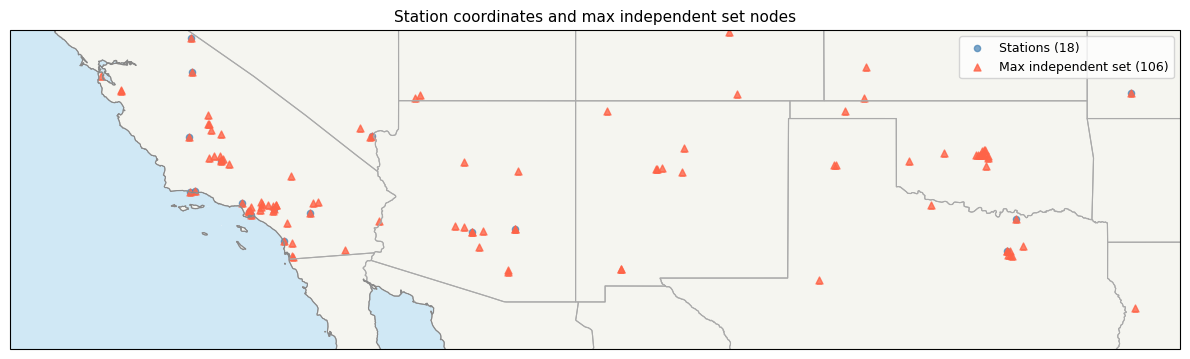

Num of charging stations 18
Num of proxy stations 88
Dallas closest node: (32.76662, -96.807086), distance: 0.9 miles
Connected to PHX? True
Connected to LA? True


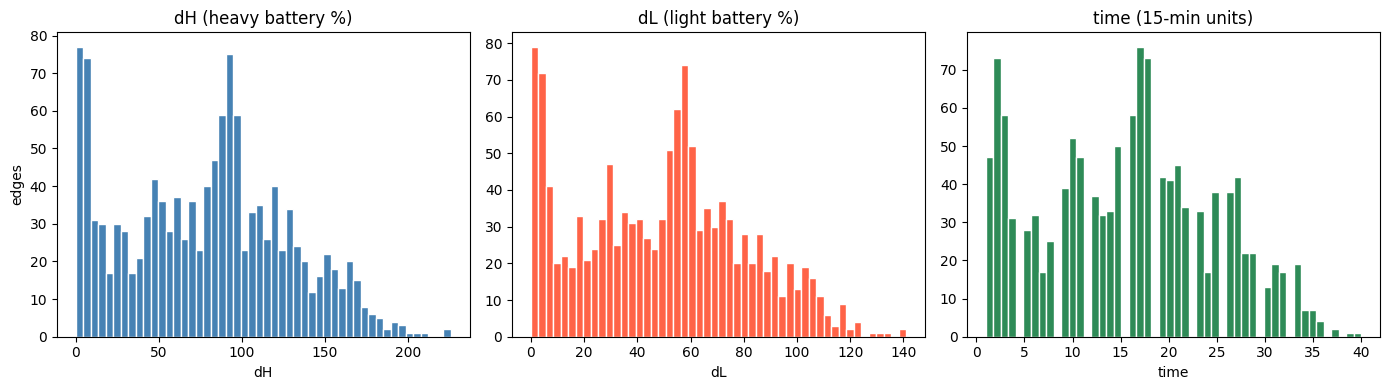

dH:   min=0.00  max=226.00  mean=78.44
dL:   min=0.00  max=141.00  mean=49.15
time: min=1.00  max=40.00  mean=15.62


In [23]:
# %%
import random
import time
import itertools
import pandas as pd
import networkx as nx
import ast
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from math import radians, sin, cos, sqrt, atan2
import json
import uuid
import os
import gurobipy as gp
from gurobipy import GRB
import Instance_v2
from parse_dicts import * 

# ============================================================
# Minimum-cardinality Steiner node set IP
# ============================================================

def solve_min_node_set_ip(G, terminal_indices, D, F=None, time_limit=300, verbose=True):
    """
    Find smallest S ⊆ V(G) containing terminal_indices such that
    G.subgraph(S) supports at least D units of flow between every pair of terminals.

    Args:
        G:                networkx Graph
        terminal_indices: nodes that must belong to S (e.g. [la, sf, phx, dal])
        D:                integer flow value required between every terminal pair
        F:                optional iterable of additional nodes fixed to S
        time_limit:       Gurobi time limit in seconds
        verbose:          print Gurobi log

    Formulation: multi-commodity flow with binary node-selection variables.
      x[i] ∈ {0,1}              -- node i is in S
      f_vars[(o,d),u,v] ∈ [0,D] -- flow on arc u->v for commodity (o,d)
      One commodity per unordered pair (o,d) in combinations(terminal_indices, 2)
      Conservation: net outflow = D at o, -D at d, 0 elsewhere
      Coupling: f_vars[(o,d),u,v] <= D*x[u]  and  f_vars[(o,d),u,v] <= D*x[v]
        -- both arc endpoints must be selected whenever the arc carries flow
    """
    if F is None:
        F = []

    for t1, t2 in itertools.combinations(terminal_indices, 2):
        if not nx.has_path(G, t1, t2):
            raise ValueError(f"Terminals {t1} and {t2} are disconnected in G -- IP infeasible.")

    # Restrict to nodes reachable from the terminals (prunes irrelevant nodes)
    reachable = set()
    for t in terminal_indices:
        reachable |= nx.node_connected_component(G, t)

    sub   = G.subgraph(sorted(reachable))
    nodes = list(sub.nodes)
    nbrs  = {n: list(sub.neighbors(n)) for n in nodes}

    # One commodity per unordered terminal pair
    pairs = list(itertools.combinations(terminal_indices, 2))

    m = gp.Model("Steiner_MinNodes_Flow")
    m.Params.LogToConsole = int(verbose)
    m.Params.TimeLimit    = time_limit

    # --- node selection variables ---
    x = m.addVars(nodes, vtype=GRB.BINARY, name="x")

    # --- flow variables: one per (OD commodity, directed arc) ---
    f_vars = {}
    for (o, d) in pairs:
        for u in nodes:
            for v in nbrs[u]:
                f_vars[(o, d, u, v)] = m.addVar(lb=0.0, ub=D, name=f"f_{o}_{d}_{u}_{v}")
    m.update()

    # --- objective: minimise non-fixed selected nodes ---
    fixed = set(terminal_indices) | set(F)
    m.setObjective(gp.quicksum(x[i] for i in nodes if i not in fixed), GRB.MINIMIZE)

    # --- fix terminals and any additional fixed nodes ---
    for i in fixed:
        if i in x:
            m.addConstr(x[i] == 1, name=f"fix_{i}")

    # --- flow conservation + arc-node coupling, one block per commodity ---
    K = len(terminal_indices)
    for (o, d) in pairs:
        for i in nodes:
            out_f = gp.quicksum(f_vars[(o, d, i, j)] for j in nbrs[i])
            in_f  = gp.quicksum(f_vars[(o, d, j, i)] for j in nbrs[i])
            rhs   = D if i == o else (-D if i == d else 0)
            m.addConstr(out_f - in_f == rhs, name=f"flow_{o}_{d}_{i}")

        for u in nodes:
            for v in nbrs[u]:
                m.addConstr(f_vars[(o, d, u, v)] <= D * x[u], name=f"tail_{o}_{d}_{u}_{v}")
                m.addConstr(f_vars[(o, d, u, v)] <= D * x[v], name=f"head_{o}_{d}_{u}_{v}")
                m.addConstr(f_vars[(o, d, u, v)] <= K)
    m.optimize()

    status = m.Status
    if status in (GRB.OPTIMAL, GRB.TIME_LIMIT):
        S   = [i for i in nodes if x[i].X > 0.5]
        obj = int(round(m.ObjVal))
        return S, obj, status
    raise RuntimeError(f"Gurobi returned status {status} -- no feasible solution found.")



# ============================================================
# Constants
# ============================================================

# add seed
random_seed = 1

random.seed(random_seed)

PROCESSED_STATIONS_DF = "data/processed/stations_data.csv"
LB = 0
# bounding box
 


# West Coast bounding box
WEST_COAST_MIN_LAT = 30
WEST_COAST_MAX_LAT = 39
WEST_COAST_MIN_LNG = -125
WEST_COAST_MAX_LNG = -92
# Truck properties
RANGE = 190 # miles
BAT_CAPACITY = 565 # kWh
 

# for a 100kwh station,
speed_curve ={0: {'speed': 3600 * 1/(35*3.6), 'minbat': 0, 'maxbat': 10},
                   1: {'speed': 3600 * 1/(25*3.6), 'minbat': 10, 'maxbat': 40},
                   2: {'speed': 3600 * 1/(37.5*3.6), 'minbat': 40, 'maxbat': 80},
                   3: {'speed': 3600 * 1/(172.5*3.6), 'minbat': 80, 'maxbat': 100}}


# Other parameters
BAT_FROM_TIME = 3600 * 1000 * .75 # battery consumption = (3600 * 1000 * .8) * (time in hrs)

DISTANCE_THRESHOLD = 30  # miles
EDGE_THRESHOLD = 190  # miles - max edge length for connectivity

# Major West Coast cities (name, lat, lng)
cities = dict(
    [('Seattle', (47.6062, -122.3321)),
    ('Portland', (45.5152, -122.6784)),
    ('San Francisco', (37.7749, -122.4194)),
    ('Los Angeles', (34.0522, -118.2437)),
    ('San Diego', (32.7157, -117.1611)),
    ('Sacramento', (38.5816, -121.4944)),
    ('Las Vegas', (36.1699, -115.1398)),
    ('Phoenix', (33.4484, -112.0740)),
    ('Reno', (39.5296, -119.8138)),
    ('Eugene', (44.0521, -123.0868)),
    ('Oakland', (37.8044, -122.2712)),
    ('San Jose', (37.3382, -121.8863)),
    ('Dallas', (32.7767, -96.7970))]
)

# ============================================================
# Functions
# ============================================================

def haversine_miles(lat1, lng1, lat2, lng2):
    """Calculate distance in miles between two lat/lng points."""
    R = 3958.8  # Earth's radius in miles

    lat1, lng1, lat2, lng2 = map(radians, [lat1, lng1, lat2, lng2])
    dlat = lat2 - lat1
    dlng = lng2 - lng1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlng/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))

    return R * c

def is_west_coast(lat, lng):
    """Check if a point is within the West Coast bounding box."""
    return (WEST_COAST_MIN_LAT <= lat <= WEST_COAST_MAX_LAT and
            WEST_COAST_MIN_LNG <= lng <= WEST_COAST_MAX_LNG)

def is_west_of_phoenix(lat, lng):
    return lng < cities['Phoenix'][1]

def find_closest_node(target_lat, target_lng, node_list):
    """Find the node in node_list closest to target coordinates."""
    min_dist = float('inf')
    closest_node = None
    closest_idx = None
    for idx, node in enumerate(node_list):
        dist = haversine_miles(target_lat, target_lng, node[0], node[1])
        if dist < min_dist:
            min_dist = dist
            closest_node = node
            closest_idx = idx
    return closest_idx, closest_node, min_dist

# ============================================================
# Load data
# ============================================================


# %%
# read each line in D_parallel_out.csv
lst = []
with open("data/D_parallel_out.csv", "r") as f:
    ctr = 0
    for line in f:
        if ctr > 0:
            # split line into 2 parts after the first comma
            parts = line.strip().split(",", 1)
            lst += parse_np_dict_string(parts[1])
        ctr += 1

other_nodes_df = pd.DataFrame(lst) 

# %%

stations_df = pd.read_csv(PROCESSED_STATIONS_DF)

stations_df['snap_to'] = stations_df['snap_to'].apply(ast.literal_eval)
stations_df.reset_index(inplace=True)

stations_df.index = stations_df['index']

# # Build pt1/pt2 coordinate tuples from the separate lat/lon columns
# other_nodes_df['pt1'] = list(zip(other_nodes_df['pt1_lat'], other_nodes_df['pt1_lon']))
# other_nodes_df['pt2'] = list(zip(other_nodes_df['pt2_lat'], other_nodes_df['pt2_lon']))

# Get unique coordinates from both pt1 and pt2
all_other_nodes = set(other_nodes_df['pt1'].tolist() + other_nodes_df['pt2'].tolist())

# Filter stations_df for West Coast
stations_west = stations_df[
    (stations_df['lat'] >= WEST_COAST_MIN_LAT) &
    (stations_df['lat'] <= WEST_COAST_MAX_LAT) &
    (stations_df['lng'] >= WEST_COAST_MIN_LNG) &
    (stations_df['lng'] <= WEST_COAST_MAX_LNG)
]

# Get station coordinates as tuples
station_coords = set(zip(stations_west['lat'], stations_west['lng']))

# Get unique nodes from other_nodes_df (West Coast only)
west_coast_nodes = [node for node in all_other_nodes if is_west_coast(node[0], node[1])]

all_selected_nodes = list(station_coords) + list(west_coast_nodes)
all_selected_nodes = list(set(all_selected_nodes))  # Remove duplicates

la_idx, la_node, la_dist = find_closest_node(cities['Los Angeles'][0], cities['Los Angeles'][1], all_selected_nodes)
sf_idx, sf_node, sf_dist = find_closest_node(cities['San Francisco'][0], cities['San Francisco'][1], all_selected_nodes)
phx_idx, phx_node, phx_dist = find_closest_node(cities['Phoenix'][0], cities['Phoenix'][1], all_selected_nodes)
dal_idx, dal_node, dal_dist = find_closest_node(cities['Dallas'][0], cities['Dallas'][1], all_selected_nodes)

terminal_nodes = [la_idx, sf_idx, phx_idx, dal_idx]

# %%
sf_idx

# %%

# Build graph; edges come from other_nodes_df filtered by bat consumption
N = nx.Graph()
for i, node in enumerate(all_selected_nodes):
    N.add_node(i, pos=node)

coord_to_idx = {coord: i for i, coord in enumerate(all_selected_nodes)}

for _, row in other_nodes_df.iterrows():
    i = coord_to_idx.get(row['pt1'])
    j = coord_to_idx.get(row['pt2'])
    if i is None or j is None or i == j:
        continue
    # Keep the minimum-bat route if multiple rows connect the same pair
    if  100 * (row['bat_L'] * 2.7778e-7)/BAT_CAPACITY <= 1000:
        dH = int(100 * (row['bat_H'] * 2.7778e-7)/BAT_CAPACITY)
        dL = int(100 * (row['bat_L'] * 2.7778e-7)/BAT_CAPACITY)
        time = int(np.ceil(row['time']/(60 * 15)))
        N.add_edge(i, j, dH=dH, dL=dL, time=time)


# %%
F = [coord_to_idx[coord] for coord in station_coords if coord in coord_to_idx]
print(len(station_coords), len(F))
print(F)
D = 100
try:
    S, obj, status  = solve_min_node_set_ip(N, terminal_nodes, 100, F=F, time_limit=300) 
    S = list(np.unique(S + F))
    print(f"D={D} → |S|={len(S)}, obj={obj}, status={status}")
except:
   print(f"IP infeasible for D={D}")


# %%

# Convert indices back to coordinates
max_independent_set = [all_selected_nodes[i] for i in S]

print(f"\nMaximum independent set size: {len(max_independent_set)}")
print(f"(Out of {len(all_selected_nodes)} West Coast nodes)")


proj = ccrs.PlateCarree()
fig, ax = plt.subplots(figsize=(12, 7), subplot_kw={'projection': proj})
ax.set_extent([WEST_COAST_MIN_LNG, WEST_COAST_MAX_LNG, WEST_COAST_MIN_LAT, WEST_COAST_MAX_LAT], crs=proj)
ax.add_feature(cfeature.LAND,      facecolor='#f5f5f0')
ax.add_feature(cfeature.OCEAN,     facecolor='#d0e8f5')
ax.add_feature(cfeature.STATES,    edgecolor='#aaaaaa', linewidth=0.8)
ax.add_feature(cfeature.COASTLINE, edgecolor='#888888', linewidth=0.8)

sc_lats = [lat for lat, lng in station_coords]
sc_lngs = [lng for lat, lng in station_coords]
ax.scatter(sc_lngs, sc_lats, s=20, color='steelblue', alpha=0.7,
           transform=proj, label=f'Stations ({len(station_coords)})')

mis_lats = [lat for lat, lng in max_independent_set]
mis_lngs = [lng for lat, lng in max_independent_set]
ax.scatter(mis_lngs, mis_lats, s=25, color='tomato', alpha=0.8, marker='^',
           transform=proj, label=f'Max independent set ({len(max_independent_set)})')

ax.legend(loc='upper right', fontsize=9)
ax.set_title('Station coordinates and max independent set nodes', fontsize=11)
plt.tight_layout()
plt.savefig('results/nodes_map.png', dpi=150, bbox_inches='tight')
plt.show()




# %%
with open('results/node_positions.json', 'w') as f:
    json.dump([all_selected_nodes[i] for i in S], f)


# Set charger_rate for nodes that correspond to stations
station_lookup = {(row['lat'], row['lng']): row['n_chargers'] * row['kw']
                  for _, row in stations_df.iterrows()}

station_nodes = []
for i, node in enumerate(all_selected_nodes):
    if node in station_lookup:
        N.nodes[i]['charger_rate'] = station_lookup[node]
        station_nodes.append(i)
    else:
        N.nodes[i]['charger_rate'] = 250 # new stations are 250 kwh, single charger 
N = N.subgraph(S).copy()


# Reindex nodes to consecutive integers and record coordinate mapping
old_to_new = {old: new for new, old in enumerate(N.nodes())}
node_coords = {old_to_new[n]: N.nodes[n]['pos'] for n in N.nodes()}
N = nx.relabel_nodes(N, old_to_new)

# Update terminal and station indices to the new numbering
la_idx   = old_to_new[la_idx]
sf_idx   = old_to_new[sf_idx]
phx_idx  = old_to_new[phx_idx]
dal_idx  = old_to_new[dal_idx]
station_nodes = [old_to_new[n] for n in station_nodes if n in old_to_new]

# print 'charger_rate' for each node
print("Num of charging stations", len(station_nodes))
print("Num of proxy stations", len(N.nodes) - len(station_nodes))
RESULTS_DIR = 'results'
NODES_FILE = os.path.join(RESULTS_DIR, 'experiment_nodes.json')
print(f"Dallas closest node: {dal_node}, distance: {dal_dist:.1f} miles")
print("Connected to PHX?", nx.has_path(N, dal_idx, phx_idx))
print("Connected to LA?", nx.has_path(N, la_idx, dal_idx))

dH_vals   = [d['dH']   for _, _, d in N.edges(data=True)]
dL_vals   = [d['dL']   for _, _, d in N.edges(data=True)]
time_vals = [d['time'] for _, _, d in N.edges(data=True)]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(dH_vals,   bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('dH (heavy battery %)')
axes[0].set_xlabel('dH'); axes[0].set_ylabel('edges')

axes[1].hist(dL_vals,   bins=50, color='tomato',    edgecolor='white')
axes[1].set_title('dL (light battery %)')
axes[1].set_xlabel('dL')

axes[2].hist(time_vals, bins=50, color='seagreen',  edgecolor='white')
axes[2].set_title('time (15-min units)')
axes[2].set_xlabel('time')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'edge_attr_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"dH:   min={min(dH_vals):.2f}  max={max(dH_vals):.2f}  mean={sum(dH_vals)/len(dH_vals):.2f}")
print(f"dL:   min={min(dL_vals):.2f}  max={max(dL_vals):.2f}  mean={sum(dL_vals)/len(dL_vals):.2f}")
print(f"time: min={min(time_vals):.2f}  max={max(time_vals):.2f}  mean={sum(time_vals)/len(time_vals):.2f}")

# commodity flow = x/365 thousand tons per day from San Jose -> Oakland. 13 ton per truck, and 10% of market (actual is 23% EV truck market share by 2030 (https://blog.ucs.org/sam-wilson/we-can-electrify-one-in-three-heavy-duty-trucks-by-2030-heres-how/#:~:text=States%20are%20taking%20the%20lead%20in%20this,even%20without%20purchase%20incentives%20(see%20graph%20below)_
def commodity_flow_to_demand(x, hrs, market_share=0.1,):
    tons_per_day = x/365
    trucks_per_day = tons_per_day / 13
    ev_trucks_per_day = trucks_per_day * market_share
    ev_trucks_per_hour = ev_trucks_per_day / 24
    return int(ev_trucks_per_hour * hrs)


In [ ]:

phx_sf = commodity_flow_to_demand(555.0 * 1000, 4)
la_phx = commodity_flow_to_demand(2816.0 * 1000, 4)
dal_phx = commodity_flow_to_demand(357.0 * 1000, 4)
sf_dal = commodity_flow_to_demand(354.0 * 1000, 4)
la_dal = commodity_flow_to_demand(1542.0 * 1000, 4)
la_sf = commodity_flow_to_demand(4568.0 * 1000, 4)
T = 4 * 30 # unit: 15 minutes; 25 hrs to allow intermediate charging on LA-SF/PHX routes
parameters = {
    'T': T, 
    'L': 100,
    'D': {(phx_idx, sf_idx): phx_sf, 
    #(la_idx, phx_idx): la_phx, (la_idx, sf_idx): la_sf, 
     (dal_idx, phx_idx): dal_phx,
    (la_idx, dal_idx): la_dal},
        'step_size': 50,
    'MAX_ITER': 1000,
    'value_for_time': 27/4, # units are 15 minutes
    'charge_nodes':  station_nodes,   
     'existing_charge_nodes': station_nodes,
    'battery_nodes': [],
    'tractor_nodes': [i for i in N.nodes if i not in station_nodes],
    'mobile_nodes': [],
    'charge_rate': {i : N.nodes[i]['charger_rate']
                   for i in N.nodes},
    'charge_cost': {(i, t): 0.6 for i in N.nodes for t in range(T)},
    'stat_cost': {i: 250000/(365*5) for i in N.nodes},
    'surplus_cost': {i: 25000/(365*5) for i in N.nodes},
    'N_tractors': np.inf,
    'N_batteries': 0,
    'N_chargers': np.inf,
    'speed_curve': speed_curve, # {0: {'speed': 67/(2.5 * 4), 'minbat': 0, 'maxbat': 100}},
    'bat_swap_time': 0,
    'tr_swap_time': 1, 
    'sources': [la_idx, phx_idx, dal_idx],
    'sinks':   [dal_idx, sf_idx, phx_idx]
}

 


# %%
instance = Instance_v2.Instance(N, parameters, ['heuristic'], seed=None)
print(parameters['D'])
soln, val, props = instance.run_DDD(LB=0, LP=False)
      

# Convert tuple keys to strings for JSON serialization
def serialize_dict(d):
    return {str(k): v for k, v in d.items()}

result = {
    'config': instance.config,
    'objective': val,
    'properties': props,
    'solution': {k: serialize_dict(v) for k, v in soln.items()
                    if isinstance(v, dict)},
}
result_file = os.path.join(RESULTS_DIR, f'SJ_Oak-chargerOnly.json')
with open(result_file, 'w') as f:
    json.dump(result, f, indent=2)




